In [1]:
import pandas as pd

# 读取数据
df = pd.read_csv('features_3_sec.csv')

# 查看前5行和列名
print(df.head())
# 查看各流派数量是否均衡
print(df['label'].value_counts())

            filename  length  chroma_stft_mean  chroma_stft_var  rms_mean  \
0  blues.00000.0.wav   66149          0.335406         0.091048  0.130405   
1  blues.00000.1.wav   66149          0.343065         0.086147  0.112699   
2  blues.00000.2.wav   66149          0.346815         0.092243  0.132003   
3  blues.00000.3.wav   66149          0.363639         0.086856  0.132565   
4  blues.00000.4.wav   66149          0.335579         0.088129  0.143289   

    rms_var  spectral_centroid_mean  spectral_centroid_var  \
0  0.003521             1773.065032          167541.630869   
1  0.001450             1816.693777           90525.690866   
2  0.004620             1788.539719          111407.437613   
3  0.002448             1655.289045          111952.284517   
4  0.001701             1630.656199           79667.267654   

   spectral_bandwidth_mean  spectral_bandwidth_var  ...  mfcc16_var  \
0              1972.744388           117335.771563  ...   39.687145   
1              2010.05

In [4]:
df = df.drop(columns=['filename', 'length'])
print(df.head())

   chroma_stft_mean  chroma_stft_var  rms_mean   rms_var  \
0          0.335406         0.091048  0.130405  0.003521   
1          0.343065         0.086147  0.112699  0.001450   
2          0.346815         0.092243  0.132003  0.004620   
3          0.363639         0.086856  0.132565  0.002448   
4          0.335579         0.088129  0.143289  0.001701   

   spectral_centroid_mean  spectral_centroid_var  spectral_bandwidth_mean  \
0             1773.065032          167541.630869              1972.744388   
1             1816.693777           90525.690866              2010.051501   
2             1788.539719          111407.437613              2084.565132   
3             1655.289045          111952.284517              1960.039988   
4             1630.656199           79667.267654              1948.503884   

   spectral_bandwidth_var  rolloff_mean   rolloff_var  ...  mfcc16_var  \
0           117335.771563   3714.560359  1.080790e+06  ...   39.687145   
1            65671.875673   

Text(0.5, 1.0, 'Feature Correlation Heatmap')

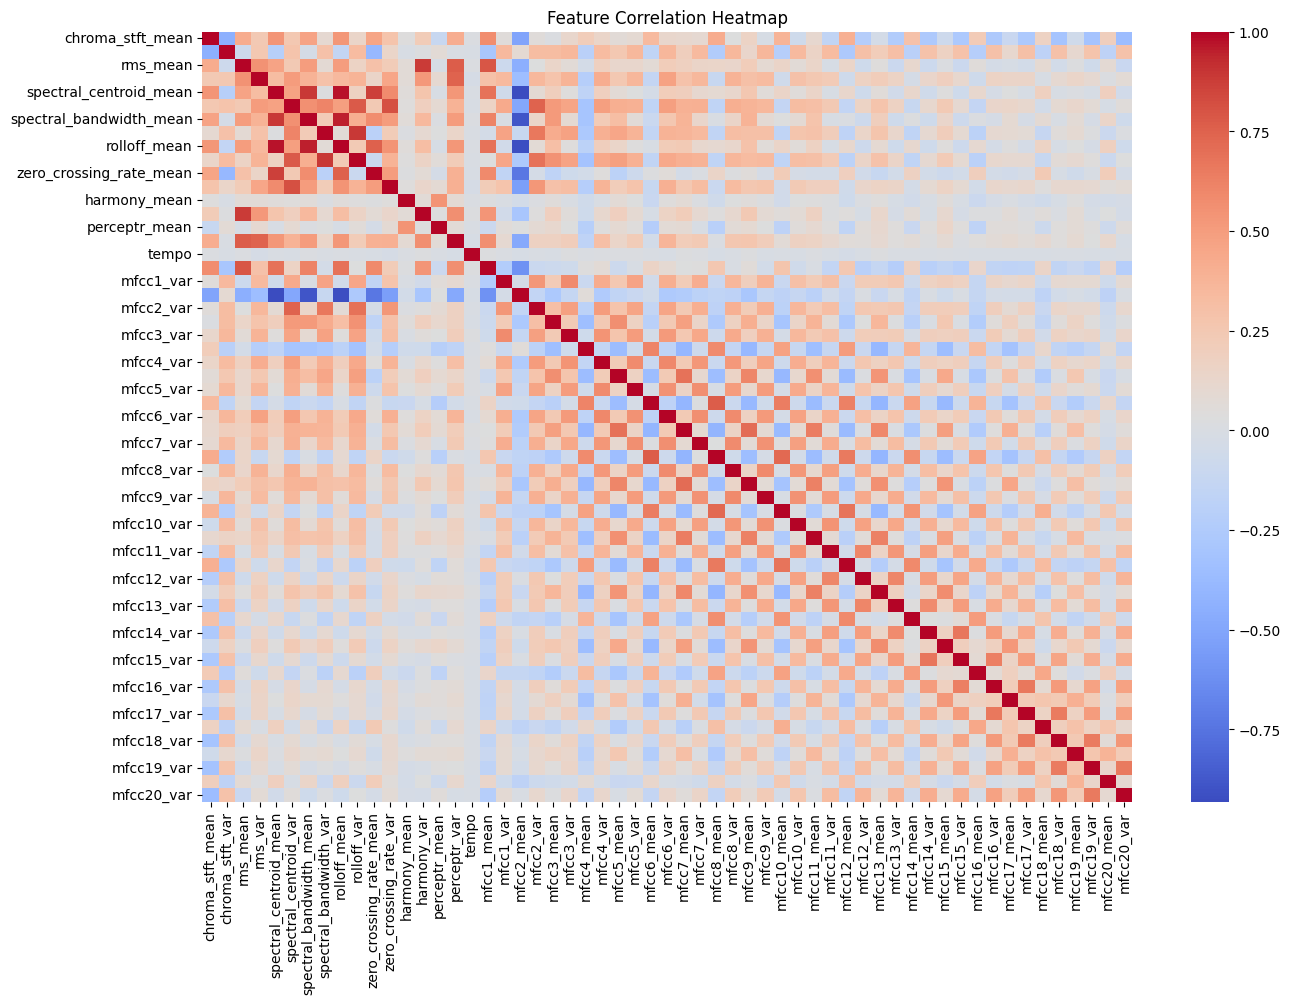

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
sns.heatmap(df.iloc[:, :-1].corr(), cmap='coolwarm') # 只对数值列做相关性
plt.title('Feature Correlation Heatmap')

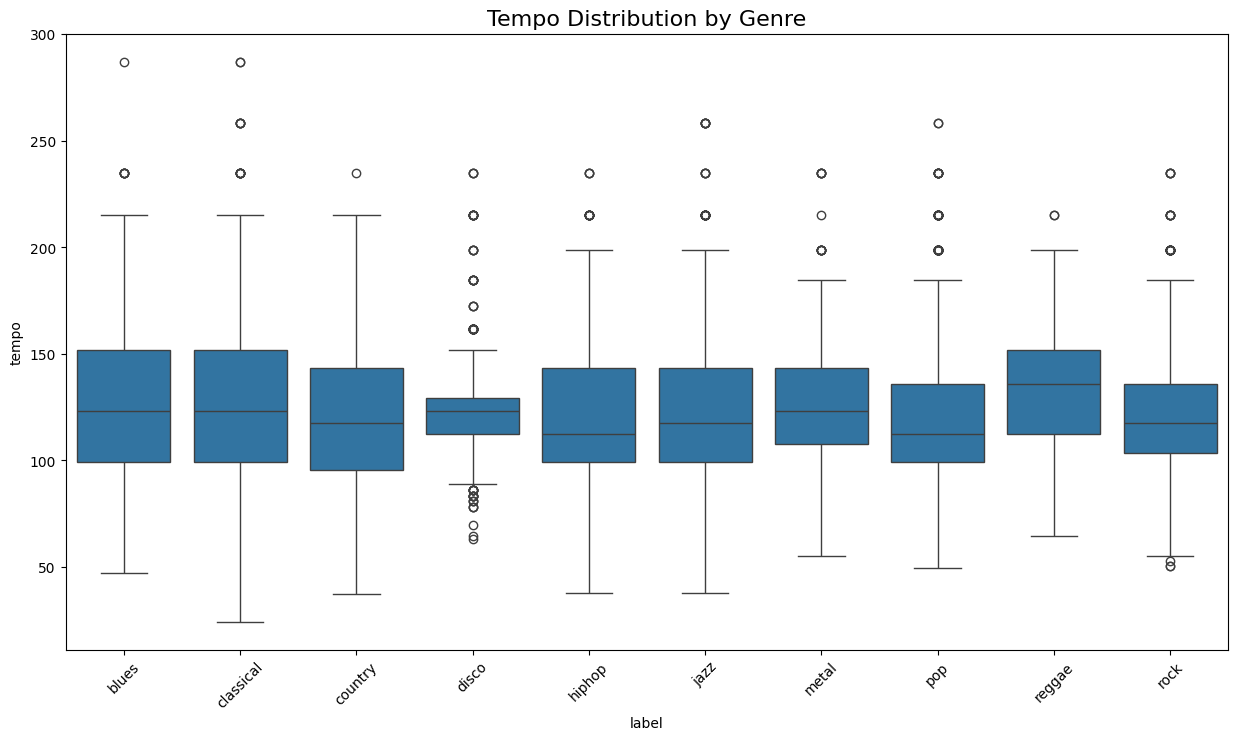

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))
sns.boxplot(x='label', y='tempo', data=df)
plt.title('Tempo Distribution by Genre', fontsize=16)
plt.xticks(rotation=45)
plt.show()

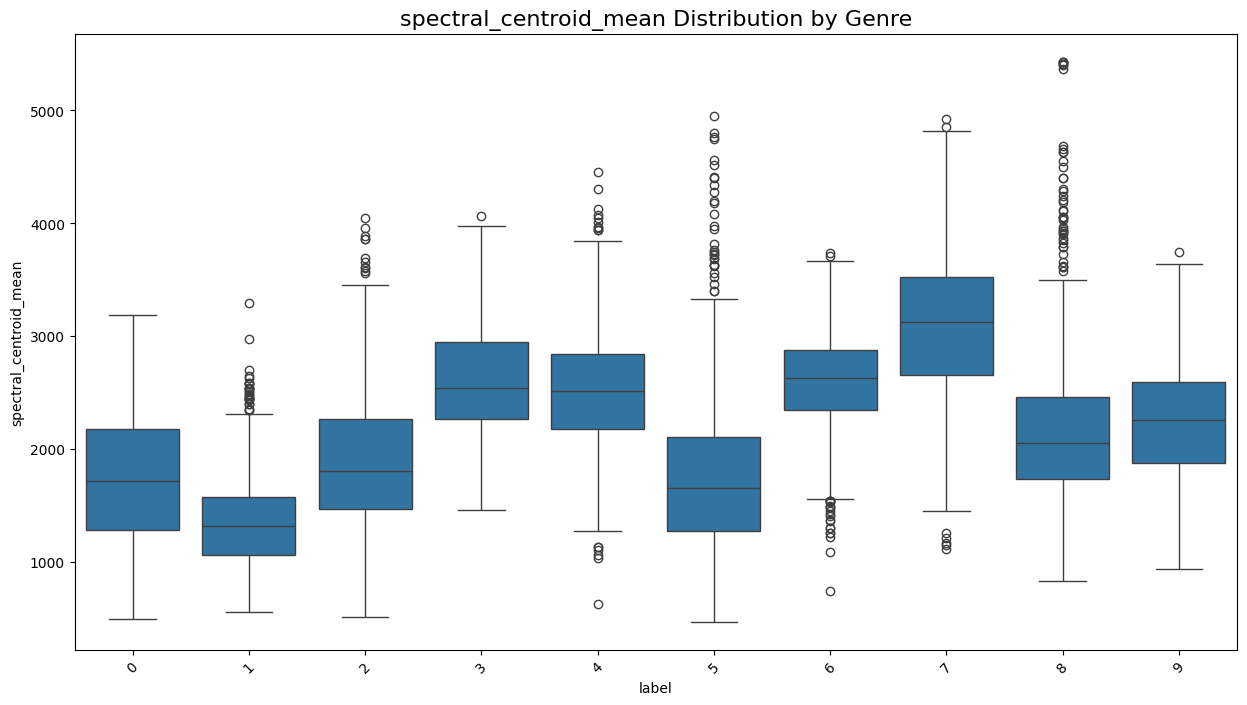

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))
sns.boxplot(x='label', y='spectral_centroid_mean', data=df)
plt.title('spectral_centroid_mean Distribution by Genre', fontsize=16)
plt.xticks(rotation=45)
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. 标签编码
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

# 2. 划分数据集 (必须在 Scaling 之前)
X = df.drop(columns=['label'])
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. 标准化
# 理由：harmony_mean 的量级可能很小，需要缩放以适应 SVM 等算法 [cite: 77]
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

param_grid_svm = {
    'svc__C': [1, 10, 50],
    'svc__kernel': ['rbf', 'poly'],
    'svc__gamma': ['scale', 'auto']
}

svm_pipeline = Pipeline([
    ('var_thresh', VarianceThreshold(threshold=0.1)),
    ('svc', SVC(probability=True, random_state=42))
])

grid_svm = GridSearchCV(svm_pipeline, param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

grid_svm.fit(X_train_scaled, y_train)

y_pred_svm = grid_svm.predict(X_test_scaled)

print(f"Optimal parameters: {grid_svm.best_params_}")
print(f"SVM Validation set best accuracy: {grid_svm.best_score_:.4f}")
print(f"SVM Test set accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

joblib.dump(grid_svm, 'svm_refined_model.pkl')

Fitting 5 folds for each of 12 candidates, totalling 60 fits
最佳参数: {'svc__C': 50, 'svc__gamma': 'auto', 'svc__kernel': 'rbf'}
SVM 验证集最佳准确率: 0.9068
SVM 测试集准确率: 0.9159
              precision    recall  f1-score   support

       blues       0.90      0.93      0.91       200
   classical       0.91      0.98      0.94       199
     country       0.86      0.89      0.87       199
       disco       0.92      0.86      0.89       200
      hiphop       0.92      0.92      0.92       200
        jazz       0.92      0.94      0.93       200
       metal       0.96      0.97      0.97       200
         pop       0.94      0.89      0.91       200
      reggae       0.91      0.92      0.91       200
        rock       0.92      0.88      0.90       200

    accuracy                           0.92      1998
   macro avg       0.92      0.92      0.92      1998
weighted avg       0.92      0.92      0.92      1998



['svm_refined_model.pkl']

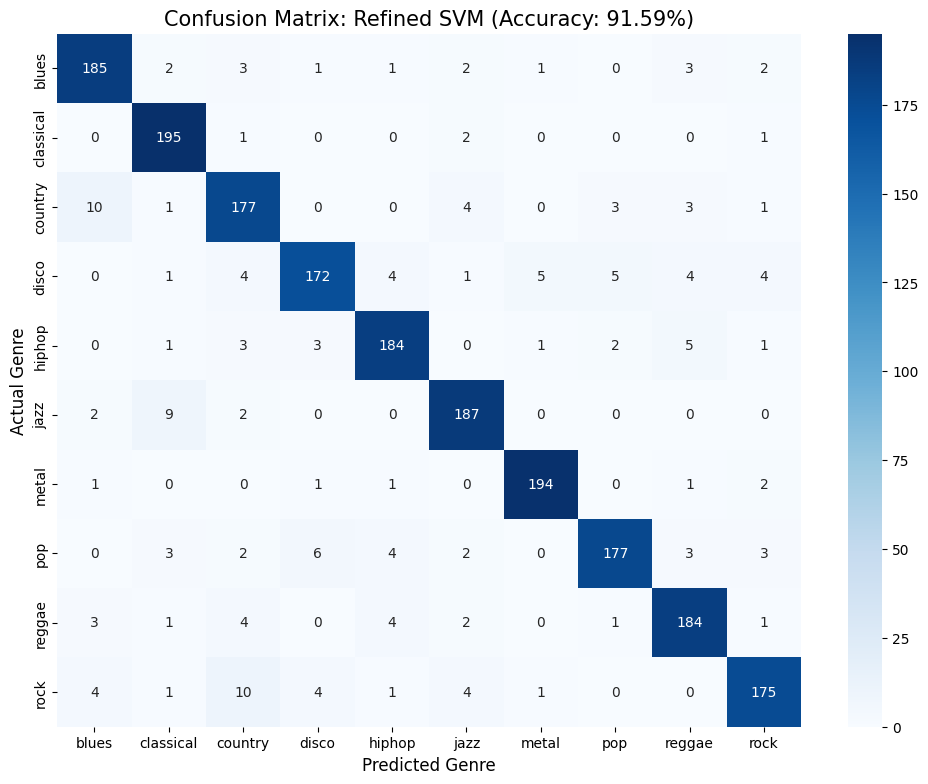

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. 计算混淆矩阵
cm = confusion_matrix(y_test, y_pred_svm)

# 2. 设置画布大小
plt.figure(figsize=(12, 9))

# 3. 绘制热力图
# annot=True 显示数字；fmt='d' 格式化为整数；cmap='Blues' 使用蓝色调
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

# 4. 添加标签和标题
plt.xlabel('Predicted Genre', fontsize=12)
plt.ylabel('Actual Genre', fontsize=12)
plt.title('Confusion Matrix: Refined SVM (Accuracy: 91.59%)', fontsize=15)

# 5. 保存图片用于报告
plt.savefig('svm_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. 初始化 SVM 模型
# 建议先使用 RBF 核函数，这是处理非线性音频特征最常用的选择
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

# 2. 训练模型
svm_model.fit(X_train_scaled, y_train)

# 3. 预测
y_pred_svm = svm_model.predict(X_test_scaled)

# 4. 基础评估
print(f"SVM 准确率: {accuracy_score(y_test, y_pred_svm):.4f}")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

SVM 准确率: 0.8458
              precision    recall  f1-score   support

       blues       0.83      0.85      0.84       200
   classical       0.86      0.96      0.91       199
     country       0.83      0.81      0.82       199
       disco       0.77      0.81      0.79       200
      hiphop       0.90      0.81      0.86       200
        jazz       0.85      0.88      0.87       200
       metal       0.92      0.92      0.92       200
         pop       0.90      0.81      0.86       200
      reggae       0.83      0.86      0.85       200
        rock       0.78      0.73      0.76       200

    accuracy                           0.85      1998
   macro avg       0.85      0.85      0.85      1998
weighted avg       0.85      0.85      0.85      1998



In [12]:
from sklearn.model_selection import cross_val_score

# 使用 5 折交叉验证评估模型稳定性
cv_scores = cross_val_score(svm_model, X_train_scaled, y_train, cv=5)
print(f"5折交叉验证平均得分: {cv_scores.mean():.4f}")

5折交叉验证平均得分: 0.8443


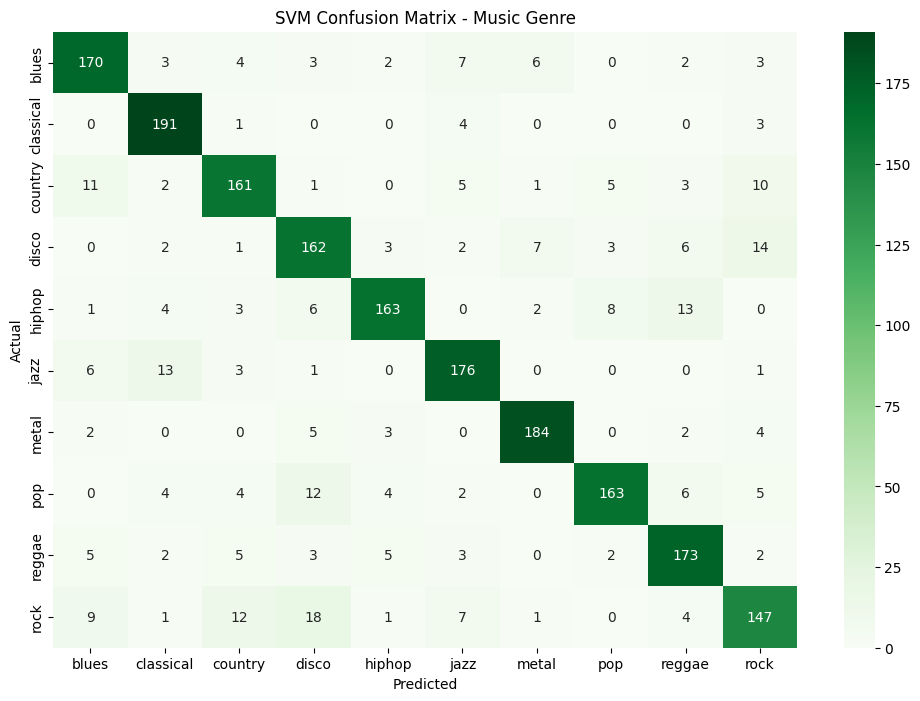

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix - Music Genre')
plt.show()

In [17]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. 初始化 XGBoost 模型
# objective='multi:softmax' 用于多分类任务，num_class 为流派总数 (10)
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    objective='multi:softmax',
    num_class=10,
    random_state=42,
    tree_method='hist' # 加速训练
)

# 2. 训练模型
xgb_model.fit(X_train_scaled, y_train)

# 3. 预测
y_pred_xgb = xgb_model.predict(X_test_scaled)

# 4. 评估
print(f"XGBoost 准确率: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

XGBoost 准确率: 0.8669
              precision    recall  f1-score   support

       blues       0.85      0.85      0.85       200
   classical       0.92      0.96      0.94       199
     country       0.79      0.83      0.81       199
       disco       0.84      0.85      0.85       200
      hiphop       0.91      0.87      0.89       200
        jazz       0.87      0.87      0.87       200
       metal       0.92      0.95      0.93       200
         pop       0.92      0.82      0.87       200
      reggae       0.83      0.87      0.85       200
        rock       0.84      0.79      0.81       200

    accuracy                           0.87      1998
   macro avg       0.87      0.87      0.87      1998
weighted avg       0.87      0.87      0.87      1998



In [18]:
from sklearn.model_selection import cross_val_score
import numpy as np

# 使用 5 折交叉验证
# 注意：这里使用 X_train_scaled，确保验证过程不接触测试集 (No Leakage)
xgb_cv_scores = cross_val_score(xgb_model, X_train_scaled, y_train, cv=5, scoring='accuracy')

print(f"XGBoost 各折准确率: {xgb_cv_scores}")
print(f"XGBoost 平均准确率: {np.mean(xgb_cv_scores):.4f}")
print(f"XGBoost 标准差: {np.std(xgb_cv_scores):.4f}")

XGBoost 各折准确率: [0.86679174 0.86741714 0.86921151 0.86420526 0.87171464]
XGBoost 平均准确率: 0.8679
XGBoost 标准差: 0.0025


In [30]:
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
import joblib

# 1. 定义 XGBoost 的参数网格
# 注意：XGBoost 的参数前缀要匹配 Pipeline 中的命名 'xgb'
# 极简快速网格
param_grid_xgb_fast = {
    'xgb__n_estimators': [100, 200], # 减少组合
    'xgb__max_depth': [4, 6],        # 树别太深
    'xgb__learning_rate': [0.1]      # 固定学习率
}


# 2. 构建包含方差过滤的 Pipeline
# 保持与 SVM 相同的 VarianceThreshold 处理
xgb_pipeline = Pipeline([
    ('var_thresh', VarianceThreshold(threshold=0.1)),
    ('xgb', xgb.XGBClassifier(
        objective='multi:softmax',
        num_class=10,
        tree_method='hist', # 使用直方图算法大幅提升搜索速度
        random_state=42
    ))
])

# 3. 初始化网格搜索
# 记得开启 n_jobs=-1 利用多核加速
grid_xgb = GridSearchCV(xgb_pipeline, param_grid_xgb, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# 4. 训练模型
grid_xgb.fit(X_train_scaled, y_train)

# 5. 评估结果
print(f"XGBoost Optimal parameters: {grid_xgb.best_params_}")
print(f"XGBoost Validation set best accuracy: {grid_xgb.best_score_:.4f}")
print(f"XGBoost Test set accuracy: {accuracy_score(y_test, grid_xgb.predict(X_test_scaled)):.4f}")

# 6. 保存模型
joblib.dump(grid_xgb, 'xgb_refined_model.pkl')

Fitting 5 folds for each of 54 candidates, totalling 270 fits


KeyboardInterrupt: 

/tmp/ipykernel_306/687333725.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


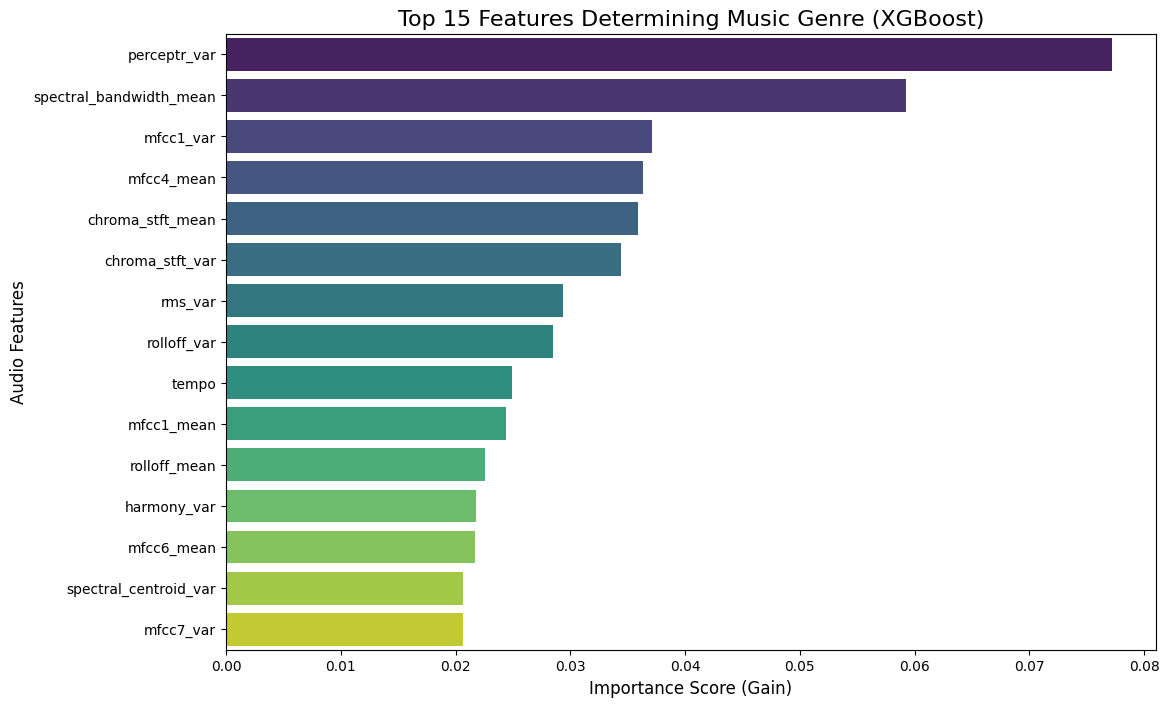

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. 获取特征重要性得分
# 默认使用的是 'gain'（增益），即该特征对模型准确率提升的平均贡献
importances = xgb_model.feature_importances_
feature_names = X.columns

# 2. 整理成 DataFrame 方便绘图
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
# 按重要性降序排列，取前 15 个最核心特征
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(15)

# 3. 绘图
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Top 15 Features Determining Music Genre (XGBoost)', fontsize=16)
plt.xlabel('Importance Score (Gain)', fontsize=12)
plt.ylabel('Audio Features', fontsize=12)
plt.show()

In [26]:
import lightgbm as lgb
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
import joblib

param_grid_lgbm = {
    'lgbm__n_estimators': [100, 200],
    'lgbm__num_leaves': [31, 63],
    'lgbm__learning_rate': [0.05, 0.1]
}


lgbm_pipeline = Pipeline([
    ('var_thresh', VarianceThreshold(threshold=0.1)),
    ('lgbm', lgb.LGBMClassifier(
        objective='multiclass',
        num_class=10,
        random_state=42,
        n_jobs=-1,
        importance_type='gain'
    ))
])

grid_lgbm = GridSearchCV(lgbm_pipeline, param_grid_lgbm, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

grid_lgbm.fit(X_train_scaled, y_train)

y_pred_lgbm = grid_lgbm.predict(X_test_scaled)

print(f"LGBM Optimal parameters: {grid_lgbm.best_params_}")
print(f"LGBM Best accuracy on the validation set: {grid_lgbm.best_score_:.4f}")
print(f"LGBM Test set accuracy: {accuracy_score(y_test, y_pred_lgbm):.4f}")
print(classification_report(y_test, y_pred_lgbm, target_names=le.classes_))


joblib.dump(grid_lgbm, 'lgbm_refined_model.joblib')

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005239 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14327
[LightGBM] [Info] Number of data points in the train set: 7992, number of used features: 57
[LightGBM] [Info] Start training from score -2.301585
[LightGBM] [Info] Start training from score -2.302835
[LightGBM] [Info] Start training from score -2.304088
[LightGBM] [Info] Start training from score -2.302835
[LightGBM] [Info] Start training from score -2.304088
[LightGBM] [Info] Start training from score -2.301585
[LightGBM] [Info] Start training from score -2.301585
[LightGBM] [Info] Start training from score -2.301585
[LightGBM] [Info] Start training from score -2.301585
[LightGBM] [Info] Start training from score -2.304088
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spli

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LGBM 最佳参数: {'lgbm__learning_rate': 0.1, 'lgbm__n_estimators': 200, 'lgbm__num_leaves': 31}
LGBM 验证集最佳准确率: 0.9109
LGBM 测试集准确率: 0.9159
              precision    recall  f1-score   support

       blues       0.91      0.91      0.91       200
   classical       0.94      0.97      0.96       199
     country       0.87      0.91      0.89       199
       disco       0.89      0.93      0.91       200
      hiphop       0.94      0.93      0.93       200
        jazz       0.92      0.92      0.92       200
       metal       0.94      0.95      0.95       200
         pop       0.94      0.85      0.89       200
      reggae       0.91      0.91      0.91       200
        rock       0.92      0.88      0.90       200

    accuracy                           0.92      1998
   macro avg       0.92      0.92      0.92      1998
weighted avg       0.92      0.92      0.92      1998



['lgbm_refined_model.joblib']

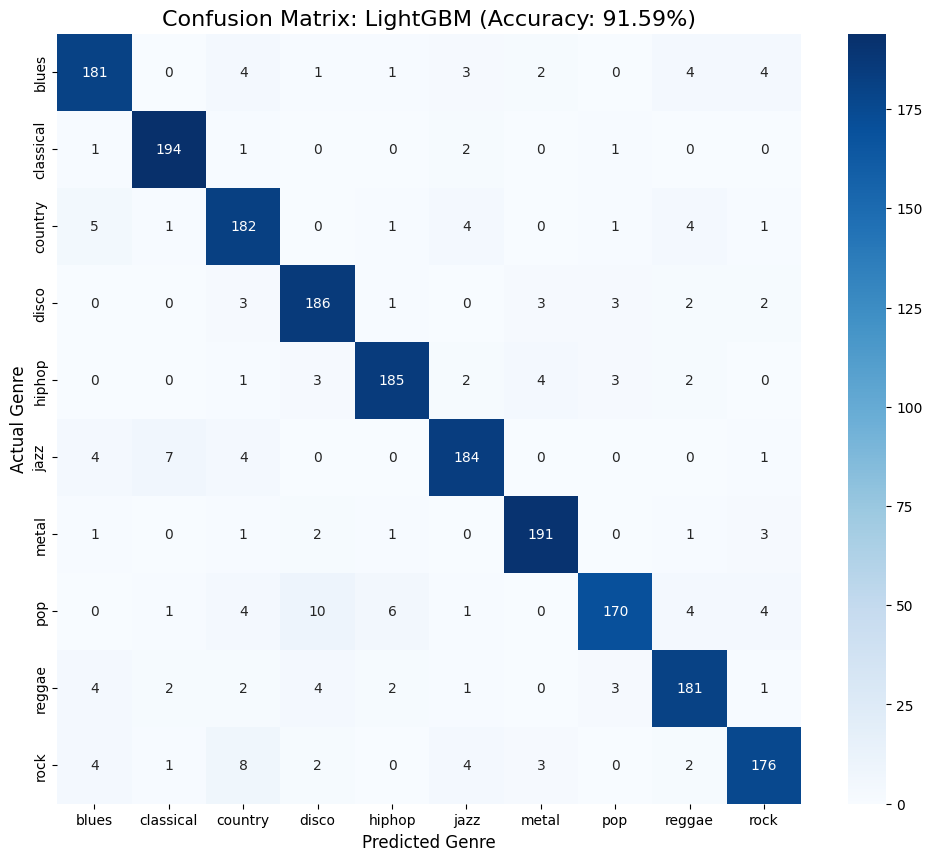

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. 计算混淆矩阵
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)

# 2. 绘图
plt.figure(figsize=(12, 10))
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: LightGBM (Accuracy: 91.59%)', fontsize=16)
plt.xlabel('Predicted Genre', fontsize=12)
plt.ylabel('Actual Genre', fontsize=12)
plt.show()

/tmp/ipykernel_306/3660546867.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=lgbm_importance_df, palette='magma')


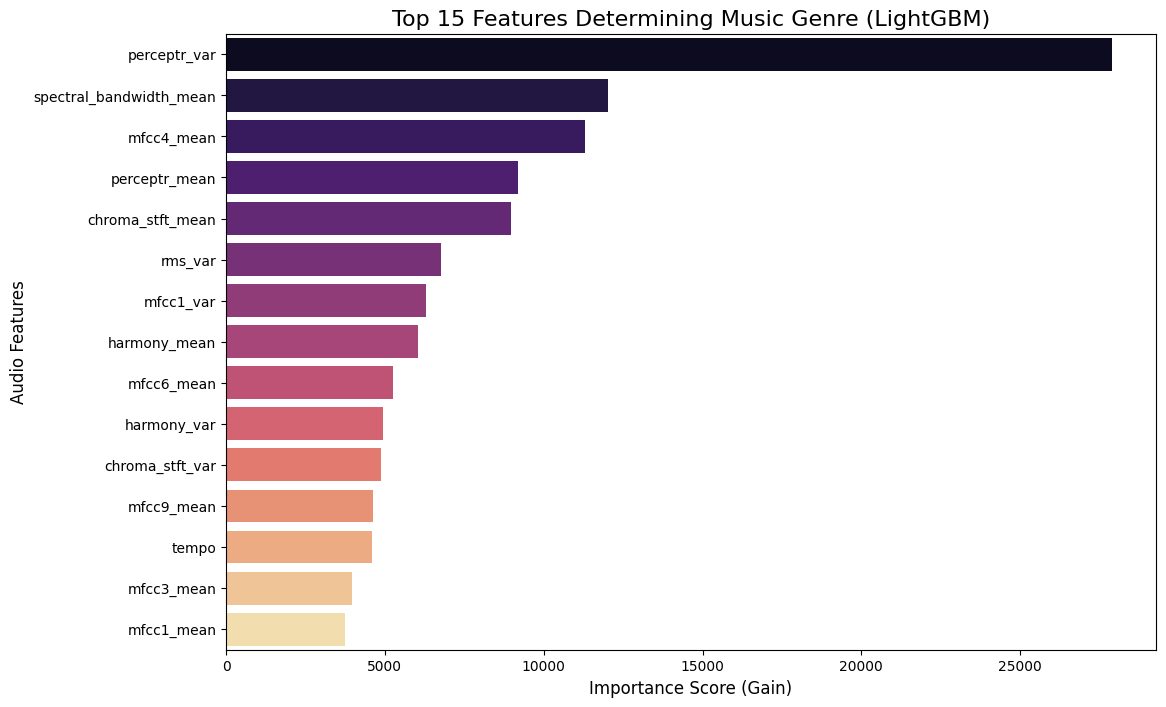

In [33]:
# 获取特征重要性（Gain）
importances_lgbm = grid_lgbm.best_estimator_.named_steps['lgbm'].feature_importances_
feature_names = X.columns # 假设 X 是你的特征集 DataFrame

# 整理数据并取前 15
lgbm_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances_lgbm})
lgbm_importance_df = lgbm_importance_df.sort_values(by='Importance', ascending=False).head(15)

# 绘图
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=lgbm_importance_df, palette='magma')
plt.title('Top 15 Features Determining Music Genre (LightGBM)', fontsize=16)
plt.xlabel('Importance Score (Gain)', fontsize=12)
plt.ylabel('Audio Features', fontsize=12)
plt.show()

In [6]:
df.isnull().sum()

,0
chroma_stft_mean,0
chroma_stft_var,0
rms_mean,0
rms_var,0
spectral_centroid_mean,0
spectral_centroid_var,0
spectral_bandwidth_mean,0
spectral_bandwidth_var,0
rolloff_mean,0
rolloff_var,0
